In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [84]:
# import the dataset
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)
df = pd.read_csv(config["input_data"]["file_1"])

In [102]:
categories = [
    df[col].dropna().unique().tolist()
    for col in df.select_dtypes(include="str").columns
]

[['Female', 'Male'],
 ['yes', 'no'],
 ['no', 'yes'],
 ['Sometimes', 'Frequently', 'Always', 'no'],
 ['no', 'yes'],
 ['no', 'yes'],
 ['no', 'Sometimes', 'Frequently', 'Always'],
 ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike'],
 ['Normal_Weight',
  'Overweight_Level_I',
  'Overweight_Level_II',
  'Obesity_Type_I',
  'Insufficient_Weight',
  'Obesity_Type_II',
  'Obesity_Type_III']]

In [69]:
# check quickly data content
df.drop_duplicates()
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
print(df.select_dtypes("str").nunique().sort_values(ascending=False))

(2111, 17)
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                        

## Day 1

In [20]:
# it is a classification, therefore we gonna use Classifier with no distinct

# X-y split; features = X, target = y
x = df.drop(columns = ["NObeyesdad"])
y = df["NObeyesdad"]

# encoding features to get only numerical values
x = pd.get_dummies(x, drop_first=True)

# encoding target too
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# preparing the train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=0) # 0-999

# create an instance classifier for the model
from sklearn.neighbors import KNeighborsClassifier

# define the number of neighbours threshold
knn = KNeighborsClassifier(n_neighbors=5) # 5 is the value by default

# train the model
knn.fit(X_train, y_train)

# predictions - array - and real values
pred = knn.predict(X_test)
pred, y_test# here test values just need to write test because not a serie

# list of uncorrect predictions
np.where(pred != y_test) # reach the index number of the rows that failed

# accuracy
print(f"The accuracy the model is {knn.score(X_test, y_test)*100: .2f}%")

The accuracy the model is  87.07%


In [26]:
# come back to the initial categorical labels
pred_labels = le.inverse_transform(pred)
real_labels = le.inverse_transform(y_test)

# check the real and predicted data
comparison = pd.DataFrame({
    "Real": real_labels,
    "Pred": pred_labels
})

comparison

,Real,Pred
0,Obesity_Type_II,Obesity_Type_II
1,Obesity_Type_I,Obesity_Type_I
2,Overweight_Level_I,Overweight_Level_I
3,Obesity_Type_III,Obesity_Type_III
4,Obesity_Type_III,Obesity_Type_III
...,...,...
629,Obesity_Type_II,Obesity_Type_II
630,Insufficient_Weight,Insufficient_Weight
631,Obesity_Type_II,Obesity_Type_II
632,Obesity_Type_I,Obesity_Type_I


## Day 2
### from data to first KNN result

In [70]:
# First, we work on numerical variables
features = df.select_dtypes(include="number")
target = df["NObeyesdad"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

# encoding target too (y_train, y_test)
from sklearn.preprocessing import OrdinalEncoder

# we need to give an order to nominal target values
all_categories = ['Insufficient_Weight',  'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
order = [cat if cat in all_categories else 'Other' for cat in all_categories]
oe = OrdinalEncoder(categories=[order])

# we apply to train ONLY
y_train = oe.fit_transform(y_train.to_frame()) # to get a df you need double square brackets it is expected syntax by the library
y_test = oe.transform(y_test.to_frame()) # NEVER FIT on test otherwise dataleackage

# create an instance of the class MinMaxScaler normalizer
normalizer = MinMaxScaler()

# .fit() determines max(x), and min(x) for every column
normalizer.fit(X_train) 

# apply the transformation + pd.df
X_train_norm = normalizer.transform(X_train)
X_train_norm = pd.DataFrame(X_train_norm, columns=X_train.columns, index=X_train.index )

X_test_norm = normalizer.transform(X_test)
X_test_norm = pd.DataFrame(X_test_norm, columns=X_test.columns, index=X_test.index )

# KNN model regressor (num values)
knn = KNeighborsRegressor(n_neighbors=10)

# train the model
knn.fit(X_train_norm, y_train)

# evaluate the model
print(f"The R2 of the model on the TEST set is: {knn.score(X_test_norm, y_test)*100: .2f}") 

The R2 of the model on the TEST set is:  87.74


**KNN 1 with all numerical variables: 87.74%**

### feature Selection

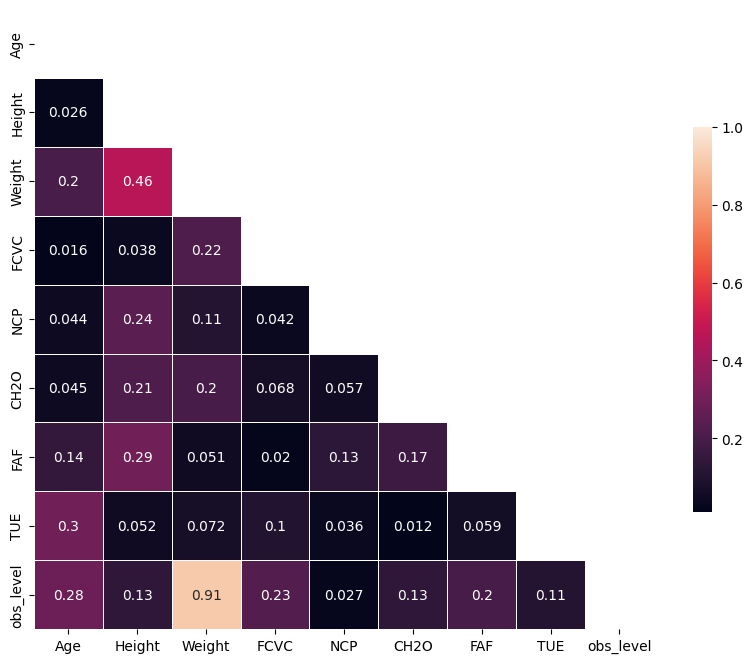

In [71]:
# map the initial target column to correlate
ObsLevel_mapping = {
    'Insufficient_Weight':0,  
    'Normal_Weight':1, 
    'Overweight_Level_I':2, 
    'Overweight_Level_II':3, 
    'Obesity_Type_I':4, 
    'Obesity_Type_II':5, 
    'Obesity_Type_III':6
}

df['obs_level'] = df['NObeyesdad'].replace(ObsLevel_mapping).astype(int)
numerical_df = df.select_dtypes(include="number")

# correlation between all numerical variables
corr=np.abs(numerical_df.corr()) # corr(x,y) = corr(y, x), corr(x,x) = 1 

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

**only variables weight and obs_level (i.e. target) are highly correlated therefore we will just keep this variable**

In [74]:
# we keep the only relevant numerical variable
X_train_reduced = X_train_norm[["Weight"]] #double squared for df
X_test_reduced = X_test_norm[["Weight"]]

knn2 = KNeighborsRegressor(n_neighbors=10)
knn2.fit(X_train_reduced, y_train)


print(f"The value of R2 on the TEST set is: {knn2.score(X_test_reduced, y_test)*100: .2f}")

The value of R2 on the TEST set is:  90.11


**KNN 2, only with correlated variable: the result is slighly better 90.11%**

In [80]:
# with scaler technique (standard d)
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled_np = scaler.transform(X_train)
X_test_scaled_np  = scaler.transform(X_test)

X_train_standarized = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
X_test_standarized  = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)

knn3 = KNeighborsRegressor(n_neighbors=10)
knn3.fit(X_train_standarized, y_train)

y_train_pred = knn3.predict(X_train_standarized)
y_test_pred = knn3.predict(X_test_standarized)

print(f"The new R2 is {knn3.score(X_test_standarized, y_test)*100: .2f}")
#Not interesting to test with only 1 variable (weight) because the neighbours will stay the same

The new R2 is  92.89


**KNN 3, with all numerical variables and scaler: the result is the highest 93%. Therefore for this dataset regarding it we should use scaler at least and keep all the variables at the end**
**normalizer all var > normalizer 1 var > scaler all var**